In [224]:
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

import matplotlib.pyplot as plt

In [225]:
# =============================================================================
# Load data
# =============================================================================

from pathlib import Path

# Paths
PREPROCESS_DIR = Path("../../output/01_preprocessing")
CLUSTER_DIR = Path("../../output/04_clustering")
VALIDATION_DIR = Path("../../output/05_validation")
DISTANCE_DIR = Path("../../output/03_distance")

DATA_DIR = Path(".")

# Google Trends panel
panel = pd.read_csv(PREPROCESS_DIR / "panel_raw_retained.csv")

# Final cluster assignments
cluster_assignments = pd.read_csv(
    CLUSTER_DIR / "final_cluster_assignments.csv"
)

# =============================================================================
# Build ranked terms within each cluster from the SAX MinDist matrix
# =============================================================================

mindist = pd.read_csv(
    DISTANCE_DIR / "sax_mindist_matrix_tiebroken.csv",
    index_col=0
)

rows = []

for cluster in sorted(cluster_assignments["cluster"].unique()):

    # Terms belonging to this cluster
    cluster_terms = (
    cluster_assignments.loc[
        cluster_assignments["cluster"] == cluster,
        "term"
        ]
        .dropna()          # remove missing terms
        .astype(str)
    )

    terms = [t for t in cluster_terms if t in mindist.index]
    # Keep only terms that exist in the MinDist matrix
    terms = [t for t in terms if t in mindist.index]

    if len(terms) == 0:
        continue

    # Pairwise distances within the cluster
    D = mindist.loc[terms, terms]

    if len(terms) == 1:
        mean_dist = pd.Series([0.0], index=terms)
    else:
        # Average distance to all OTHER members of the cluster
        mean_dist = (D.sum(axis=1) / (len(terms) - 1))

    ranked = (
        mean_dist
        .sort_values()
        .reset_index()
    )

    ranked.columns = ["term", "mean_distance"]
    ranked["cluster"] = cluster
    ranked["core_rank"] = range(1, len(ranked) + 1)

    rows.append(ranked)

core_terms = pd.concat(rows, ignore_index=True)

print(f"Constructed rankings for {core_terms['cluster'].nunique()} clusters.")
print(core_terms.head())

# Market data
MARKET_DIR = Path("../../data/shock_detection")

market_data = {
    "S&P500": pd.read_csv(MARKET_DIR / "SP500_data.csv"),
    "NASDAQ100": pd.read_csv(MARKET_DIR / "NASDAQ100_data.csv"),
    "DowJones": pd.read_csv(MARKET_DIR / "DOWJONES_data.csv"),
    "Russell2000": pd.read_csv(MARKET_DIR / "RUSSELL2000_data.csv"),
}

print(f"Panel shape: {panel.shape}")
print(f"Clusters: {cluster_assignments.shape}")
print(f"Core terms: {core_terms.shape}")

Constructed rankings for 10 clusters.
                    term  mean_distance  cluster  core_rank
0             nba scores      25.035388        1          1
1         lightning game      25.515080        1          2
2  golden state warriors      25.894188        1          3
3     colorado avalanche      26.043420        1          4
4         boston celtics      26.092666        1          5
Panel shape: (1612, 848)
Clusters: (847, 2)
Core terms: (846, 4)


In [226]:
# =============================================================================
# Ranked terms within each cluster
# =============================================================================

ranking = (
    core_terms
    .sort_values(["cluster", "core_rank"])
    .reset_index(drop=True)
)

clusters = sorted(ranking["cluster"].unique())

print(f"{len(clusters)} clusters found")
print(clusters)

ranking.head()

10 clusters found
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


,term,mean_distance,cluster,core_rank
0,nba scores,25.035388,1,1
1,lightning game,25.515080,1,2
2,golden state warriors,25.894188,1,3
3,colorado avalanche,26.043420,1,4
4,boston celtics,26.092666,1,5


In [227]:
# =============================================================================
# Build term lists for each representation
# =============================================================================

def get_cluster_terms(cluster, representation):
    """
    Returns the list of terms to use for one cluster.
    """

    # 100% = every term assigned to the cluster
    if representation == "100%":
        return (
            cluster_assignments.loc[
                cluster_assignments["cluster"] == cluster,
                "term"
            ]
            .tolist()
        )

    # Otherwise use ranked core terms
    ranked = (
        core_terms.loc[
            core_terms["cluster"] == cluster
        ]
        .sort_values("core_rank")
    )

    if representation == "centroid":
        return ranked["term"].iloc[:1].tolist()

    frac = float(representation.replace("%", "")) / 100

    n = max(1, int(np.ceil(len(ranked) * frac)))

    return ranked["term"].iloc[:n].tolist()

In [228]:
for rep in ["centroid", "10%", "25%", "50%", "75%", "100%"]:
    print(f"\n{rep}")

    for c in [1, 2]:
        terms = get_cluster_terms(c, rep)
        print(f"Cluster {c}: {len(terms)} terms")


centroid
Cluster 1: 1 terms
Cluster 2: 1 terms

10%
Cluster 1: 5 terms
Cluster 2: 12 terms

25%
Cluster 1: 11 terms
Cluster 2: 29 terms

50%
Cluster 1: 21 terms
Cluster 2: 58 terms

75%
Cluster 1: 32 terms
Cluster 2: 87 terms

100%
Cluster 1: 42 terms
Cluster 2: 115 terms


In [229]:
# =============================================================================
# Build cluster indices
# =============================================================================

def build_cluster_indices(representation):

    indices = pd.DataFrame()

    indices["Time"] = pd.to_datetime(panel["Unnamed: 0"])

    for cluster in clusters:

        terms = get_cluster_terms(cluster, representation)

        terms = [t for t in terms if t in panel.columns]

        if len(terms) == 0:
            indices[f"cluster_{cluster}"] = np.nan
        else:
            indices[f"cluster_{cluster}"] = panel[terms].mean(axis=1)

    return indices

In [230]:
def build_single_cluster_index(cluster, representation):

    indices = pd.DataFrame()

    indices["Time"] = panel["Unnamed: 0"]

    terms = get_cluster_terms(cluster, representation)
    terms = [t for t in terms if t in panel.columns]

    if len(terms) == 0:
        raise ValueError(
            f"No terms found for cluster {cluster} "
            f"({representation})"
        )

    indices[f"cluster_{cluster}"] = panel[terms].mean(axis=1)

    return indices

In [231]:
centroid_indices = build_cluster_indices("centroid")
top10_indices = build_cluster_indices("10%")
top25_indices = build_cluster_indices("25%")
top50_indices = build_cluster_indices("50%")
top75_indices = build_cluster_indices("75%")
top100_indices = build_cluster_indices("100%")

print(centroid_indices.shape)
centroid_indices.head()

(1612, 11)


,Time,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8,cluster_9,cluster_10
0,2022-01-01,30.0,53.0,26.0,13.0,2.0,4.0,5.0,88.0,4.0,90.0
1,2022-01-02,31.0,49.0,32.0,15.0,2.0,4.0,11.0,84.0,4.0,81.0
2,2022-01-03,21.0,61.0,79.0,53.0,2.0,5.0,32.0,66.0,4.0,60.0
3,2022-01-04,30.0,79.0,99.0,69.0,2.0,7.0,5.0,74.0,4.0,60.0
4,2022-01-05,29.0,74.0,91.0,66.0,3.0,7.0,3.0,64.0,3.0,53.0


In [232]:
market_data["S&P500"].head()

,Time,price,rolling_avg,deviation_pct,shock_up,shock_down,shock
0,2022-01-03,36585.058594,NaN,NaN,False,False,False
1,2022-01-04,36799.648438,NaN,NaN,False,False,False
2,2022-01-05,36407.109375,NaN,NaN,False,False,False
3,2022-01-06,36236.468750,NaN,NaN,False,False,False
4,2022-01-07,36231.660156,NaN,NaN,False,False,False


In [233]:
# =============================================================================
# Prepare market target
# =============================================================================

def prepare_market(df):

    df = df.copy()

    df["return"] = np.log(df["price"]).diff()

    # 5-day realized volatility
    df["target"] = (
        df["return"]
        .rolling(5)
        .std()
        .shift(-1)
    )

    return df

markets = {
    name: prepare_market(df)
    for name, df in market_data.items()
}

In [234]:
markets["S&P500"][["Time", "price", "return", "target"]].head(10)


,Time,price,return,target
0,2022-01-03,36585.058594,NaN,NaN
1,2022-01-04,36799.648438,0.005848,NaN
2,2022-01-05,36407.109375,-0.010724,NaN
3,2022-01-06,36236.468750,-0.004698,NaN
4,2022-01-07,36231.660156,-0.000133,0.006148
5,2022-01-10,36068.871094,-0.004503,0.005875
6,2022-01-11,36252.019531,0.005065,0.004095
7,2022-01-12,36290.320312,0.001056,0.004141
8,2022-01-13,36113.621094,-0.004881,0.004652
9,2022-01-14,35911.808594,-0.005604,0.007706


In [235]:
def make_dataset(cluster_indices, market):

    market = market.copy()

    market["Time"] = pd.to_datetime(market["Time"])

    df = cluster_indices.merge(
        market[["Time", "target"]],
        on="Time",
        how="inner"
    )

    df = df.dropna().reset_index(drop=True)

    X = df.drop(columns=["Time", "target"])
    y = df["target"]

    return X, y

In [236]:
X, y = make_dataset(
    centroid_indices,
    markets["S&P500"]
)

print(X.shape)
print(y.shape)

(1100, 10)
(1100,)


In [237]:
def evaluate_representation(representation, market_name):

    cluster_indices = build_cluster_indices(representation)

    X, y = make_dataset(
        cluster_indices,
        markets[market_name]
    )

    split = int(len(X) * 0.8)

    X_train = X.iloc[:split]
    X_test  = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test  = y.iloc[split:]

    model = LinearRegression()

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    return {
        "Representation": representation,
        "Market": market_name,
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred)
    }

In [238]:
evaluate_representation(
    "centroid",
    "S&P500"
)

{'Representation': 'centroid',
 'Market': 'S&P500',
 'RMSE': np.float64(0.0036989607965636395),
 'MAE': 0.002945875768959291,
 'R2': -0.5270731645132534}

In [239]:
representations = [
    "centroid",
    "10%",
    "25%",
    "50%",
    "75%",
    "100%"
]

results = []

for market in markets:

    for rep in representations:

        results.append(
            evaluate_representation(rep, market)
        )

results = pd.DataFrame(results)

results

,Representation,Market,RMSE,MAE,R2
0,centroid,S&P500,0.003699,0.002946,-0.527073
1,10%,S&P500,0.002889,0.002294,0.068282
2,25%,S&P500,0.006983,0.003830,-4.442246
3,50%,S&P500,0.004358,0.003338,-1.120059
4,75%,S&P500,0.003896,0.003214,-0.694161
5,100%,S&P500,0.003798,0.003095,-0.609693
6,centroid,NASDAQ100,0.004685,0.003903,-0.917802
7,10%,NASDAQ100,0.003428,0.002907,-0.026774
8,25%,NASDAQ100,0.008546,0.005094,-5.381353
9,50%,NASDAQ100,0.005683,0.004700,-1.822055


In [240]:
for rep in ["centroid", "10%", "25%", "50%", "75%", "100%"]:
    print(f"\n{rep}")
    for c in clusters:
        print(c, len(get_cluster_terms(c, rep)))


centroid
1 1
2 1
3 1
4 1
5 1
6 1
7 1
8 1
9 1
10 1

10%
1 5
2 12
3 23
4 12
5 3
6 4
7 8
8 8
9 3
10 11

25%
1 11
2 29
3 57
4 29
5 7
6 10
7 19
8 19
9 7
10 28

50%
1 21
2 58
3 113
4 58
5 14
6 19
7 37
8 37
9 13
10 55

75%
1 32
2 87
3 170
4 87
5 21
6 28
7 55
8 56
9 20
10 82

100%
1 42
2 115
3 227
4 116
5 28
6 37
7 73
8 74
9 26
10 109


In [241]:
from arch import arch_model

def prepare_garch_dataset(cluster_indices, market):

    df = market.copy()

    # Daily log returns
    df["Return"] = np.log(df["price"]).diff()

    df = df.dropna().reset_index(drop=True)

    # ------------------------
    # Fit GARCH(1,1)
    # ------------------------

    model = arch_model(
        df["Return"],
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="normal",
        rescale=False,
    )

    result = model.fit(disp="off")

    df["GARCH_Vol"] = result.conditional_volatility

    # Realized volatility over the next 5 trading days
    df["Volatility_tomorrow"] = (
        df["Return"]
        .rolling(window=5)
        .std()
        .shift(-5)
    )

    # Merge with cluster indices
    df["Time"] = pd.to_datetime(df["Time"])
    cluster_indices["Time"] = pd.to_datetime(cluster_indices["Time"])

    df = df.merge(
        cluster_indices,
        on="Time",
        how="left"
    )

    df = df.dropna().reset_index(drop=True)

    return df

In [242]:
def evaluate_representation(representation, cluster, market_name):

    cluster_indices = build_single_cluster_index(
        cluster,
        representation
    )

    df = prepare_garch_dataset(
        cluster_indices,
        markets[market_name]
    )

    cluster_cols = [f"cluster_{cluster}"]

    X_baseline = df[["GARCH_Vol"]]

    X_enhanced = df[
        ["GARCH_Vol"] + cluster_cols
    ]

    y = df["Volatility_tomorrow"]

    split = int(len(df) * 0.8)

    Xb_train = X_baseline.iloc[:split]
    Xb_test = X_baseline.iloc[split:]

    Xe_train = X_enhanced.iloc[:split]
    Xe_test = X_enhanced.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    baseline = LinearRegression()
    baseline.fit(Xb_train, y_train)

    enhanced = LinearRegression()
    enhanced.fit(Xe_train, y_train)

    pred_base = baseline.predict(Xb_test)
    pred_enh = enhanced.predict(Xe_test)

    rmse_base = np.sqrt(
        mean_squared_error(y_test, pred_base)
    )

    rmse_enh = np.sqrt(
        mean_squared_error(y_test, pred_enh)
    )

    mae_base = mean_absolute_error(
        y_test,
        pred_base,
    )

    mae_enh = mean_absolute_error(
        y_test,
        pred_enh,
    )

    oos_r2 = 1 - (
        np.sum((y_test - pred_enh) ** 2)
        /
        np.sum((y_test - y_train.mean()) ** 2)
    )

    return {
    "Representation": representation,
    "Market": market_name,
    "Baseline RMSE": rmse_base,
    "Enhanced RMSE": rmse_enh,
    "Baseline MAE": mae_base,
    "Enhanced MAE": mae_enh,
    "OOS R2": oos_r2,
}, df

In [243]:
debug_df[[
    "Time",
    "Return",
    "GARCH_Vol",
    "Volatility_tomorrow"
]].head(15)

,Time,Return,GARCH_Vol,Volatility_tomorrow
0,2022-01-11,0.005065,0.009788,0.006047
1,2022-01-12,0.001056,0.009389,0.004119
2,2022-01-13,-0.004881,0.008911,0.003742
3,2022-01-14,-0.005604,0.008641,0.007017
4,2022-01-18,-0.015245,0.008446,0.006467
5,2022-01-19,-0.009654,0.009465,0.006198
6,2022-01-20,-0.008983,0.009545,0.006018
7,2022-01-21,-0.013048,0.009545,0.008058
8,2022-01-24,0.002889,0.010027,0.009011
9,2022-01-25,-0.001945,0.009530,0.008316


In [244]:
representations = {
    "centroid": 1,
    "1%": 0.01,
    "5%": 0.05,
    "7.5%": 0.075,
    "10%": 0.10,
    "15%": 0.15,
    "20%": 0.20,
    "25%": 0.25,
    "30%": 0.30,
    "40%": 0.40,
    "50%": 0.50,
    "75%": 0.75,
    "100%": 1.00,
}

results = []

clusters = sorted(cluster_assignments["cluster"].unique())

for market in markets:

    print(market)

    for rep in representations:

        print(" ", rep)

        for cluster in clusters:

            result, _ = evaluate_representation(
                rep,
                cluster,
                market,
            )

            result["Cluster"] = cluster

            results.append(result)

results = pd.DataFrame(results)

S&P500
  centroid
  1%
  5%
  7.5%
  10%
  15%
  20%
  25%
  30%
  40%
  50%
  75%
  100%
NASDAQ100
  centroid
  1%
  5%
  7.5%
  10%
  15%
  20%
  25%
  30%
  40%
  50%
  75%
  100%
DowJones
  centroid
  1%
  5%
  7.5%
  10%
  15%
  20%
  25%
  30%
  40%
  50%
  75%
  100%
Russell2000
  centroid
  1%
  5%
  7.5%
  10%
  15%
  20%
  25%
  30%
  40%
  50%
  75%
  100%


In [245]:
df[["Time","Return","Volatility_tomorrow"]].head(10)

,Time,Return,Volatility_tomorrow
0,2022-01-11,0.005065,0.006047
1,2022-01-12,0.001056,0.004119
2,2022-01-13,-0.004881,0.003742
3,2022-01-14,-0.005604,0.007017
4,2022-01-18,-0.015245,0.006467
5,2022-01-19,-0.009654,0.006198
6,2022-01-20,-0.008983,0.006018
7,2022-01-21,-0.013048,0.008058
8,2022-01-24,0.002889,0.009011
9,2022-01-25,-0.001945,0.008316


In [247]:
results = []

clusters = sorted(cluster_assignments["cluster"].unique())

for representation in representations:
    print(representation)

    for cluster in clusters:
        print(f"  Cluster {cluster}")

        for market in markets:

            result, _ = evaluate_representation(
                representation,
                cluster,
                market
            )

            result["Cluster"] = cluster

            results.append(result)

results_df = pd.DataFrame(results)

results_df

centroid
  Cluster 1
  Cluster 2
  Cluster 3
  Cluster 4
  Cluster 5
  Cluster 6
  Cluster 7
  Cluster 8
  Cluster 9
  Cluster 10
1%
  Cluster 1
  Cluster 2
  Cluster 3
  Cluster 4
  Cluster 5
  Cluster 6
  Cluster 7
  Cluster 8
  Cluster 9
  Cluster 10
5%
  Cluster 1
  Cluster 2
  Cluster 3
  Cluster 4
  Cluster 5
  Cluster 6
  Cluster 7
  Cluster 8
  Cluster 9
  Cluster 10
7.5%
  Cluster 1
  Cluster 2
  Cluster 3
  Cluster 4
  Cluster 5
  Cluster 6
  Cluster 7
  Cluster 8
  Cluster 9
  Cluster 10
10%
  Cluster 1
  Cluster 2
  Cluster 3
  Cluster 4
  Cluster 5
  Cluster 6
  Cluster 7
  Cluster 8
  Cluster 9
  Cluster 10
15%
  Cluster 1
  Cluster 2
  Cluster 3
  Cluster 4
  Cluster 5
  Cluster 6
  Cluster 7
  Cluster 8
  Cluster 9
  Cluster 10
20%
  Cluster 1
  Cluster 2
  Cluster 3
  Cluster 4
  Cluster 5
  Cluster 6
  Cluster 7
  Cluster 8
  Cluster 9
  Cluster 10
25%
  Cluster 1
  Cluster 2
  Cluster 3
  Cluster 4
  Cluster 5
  Cluster 6
  Cluster 7
  Cluster 8
  Cluster 9
  Cluster

,Representation,Market,Baseline RMSE,Enhanced RMSE,Baseline MAE,Enhanced MAE,OOS R2,Cluster
0,centroid,S&P500,0.002973,0.002959,0.002411,0.002391,0.147639,1
1,centroid,NASDAQ100,0.003566,0.003538,0.002918,0.002883,0.383518,1
2,centroid,DowJones,0.004729,0.004692,0.003762,0.003718,0.423092,1
3,centroid,Russell2000,0.004595,0.004583,0.003720,0.003698,0.069954,1
4,centroid,S&P500,0.002973,0.002977,0.002411,0.002418,0.137404,2
...,...,...,...,...,...,...,...,...
515,100%,Russell2000,0.004595,0.004579,0.003720,0.003713,0.071247,9
516,100%,S&P500,0.002973,0.003016,0.002411,0.002442,0.114463,10
517,100%,NASDAQ100,0.003566,0.003822,0.002918,0.003040,0.280867,10
518,100%,DowJones,0.004729,0.005075,0.003762,0.003951,0.325236,10


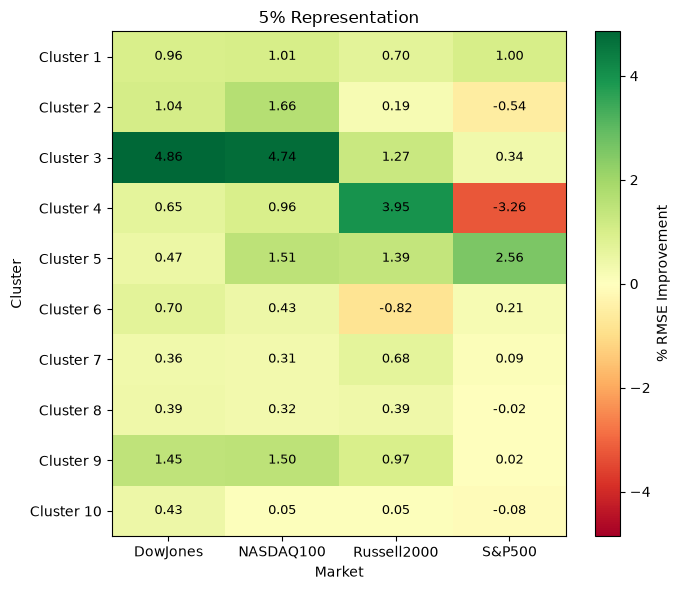

In [253]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm

# -----------------------------
# Choose representation
# -----------------------------
rep = "5%"      # Change to "centroid", "10%", "100%", etc.

# -----------------------------
# Build heatmap
# -----------------------------
heatmap_data = (
    results_df.loc[results_df["Representation"] == rep]
    .pivot(
        index="Cluster",
        columns="Market",
        values="RMSE Improvement (%)"
    )
    .sort_index()
)

# -----------------------------
# Plot
# -----------------------------
limit = np.nanmax(np.abs(heatmap_data.values))

fig, ax = plt.subplots(figsize=(7,6))

im = ax.imshow(
    heatmap_data.values,
    cmap="RdYlGn",
    norm=TwoSlopeNorm(
        vmin=-limit,
        vcenter=0,
        vmax=limit
    ),
    aspect="auto"
)

# Axis labels
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels([f"Cluster {i}" for i in heatmap_data.index])

# Numbers
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        ax.text(
            j,
            i,
            f"{heatmap_data.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color="black"
        )

plt.colorbar(im, label="% RMSE Improvement")

ax.set_title(f"{rep} Representation")
ax.set_xlabel("Market")
ax.set_ylabel("Cluster")

plt.tight_layout()
plt.show()